# Import libraries

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load ground truth

In [2]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

In [3]:
gt_df = load_gt("../data/thumos-14/annotations/thumos_14_anno.json")

# Load prediction file

In [4]:
with open("../exps/thumos/actionformer_i3d/result_detection.json", "r") as f:
    predictions = json.load(f)
    
rows_predictions = []
for video_id, segments in predictions["results"].items():
    for s in segments:
        rows_predictions.append(
            {
                "video_id": video_id,
                "start": s["segment"][0],
                "end": s["segment"][1],
                "label": s["label"],
                "score": s["score"],
            }
        )

predictions_df = pd.DataFrame(rows_predictions)
predictions_df.head()

,video_id,start,end,label,score
0,video_test_0000004,0.57,1.61,CricketShot,0.5349
1,video_test_0000004,20.60,21.86,CricketShot,0.5166
2,video_test_0000004,0.35,1.07,CricketBowling,0.4968
3,video_test_0000004,30.85,32.79,CricketShot,0.3264
4,video_test_0000004,21.35,22.03,CricketShot,0.3038


In [5]:
gt_df[gt_df['subset'] == 'training'].shape

(3003, 6)

# Explore ground truth

<Axes: title={'center': 'Number of Videos per Action Class'}, xlabel='label'>

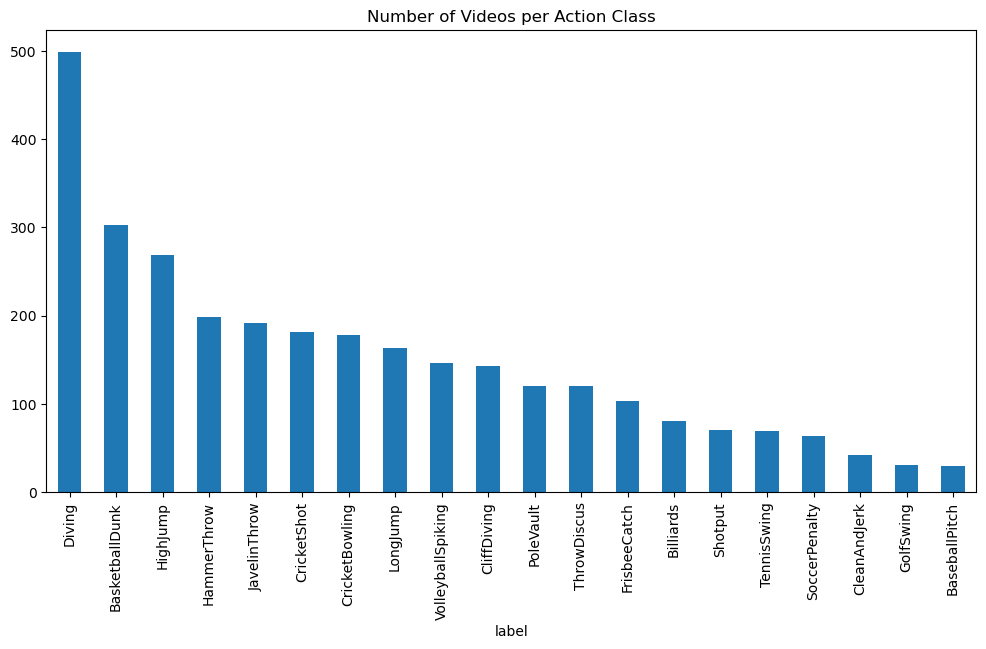

In [6]:
gt_df[gt_df['subset'] == 'training'].groupby("label")["video_id"].count().sort_values(ascending=False).plot(
    kind="bar", figsize=(12, 6), title="Number of Videos per Action Class"
)

# Plot Prediction against Ground Truth

In [7]:
def plot_predictions_vs_gt(predictions_df, gt_df, video_id, confidence_threshold=0.04):
    # predictions for the video
    predicted_video = predictions_df[
        (predictions_df["video_id"] == video_id)
        & (predictions_df["score"] > confidence_threshold)
    ]
    # ground truth for the video
    video = gt_df[gt_df["video_id"] == video_id]

    # Plot predictions against ground truth
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for _, row in predicted_video.iterrows():
        ax[0].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[0].set_title("Prediction")

    for _, row in video.iterrows():
        ax[1].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[1].set_title("Ground Truth")

    plt.xlabel("Second")
    plt.tight_layout()
    plt.show()

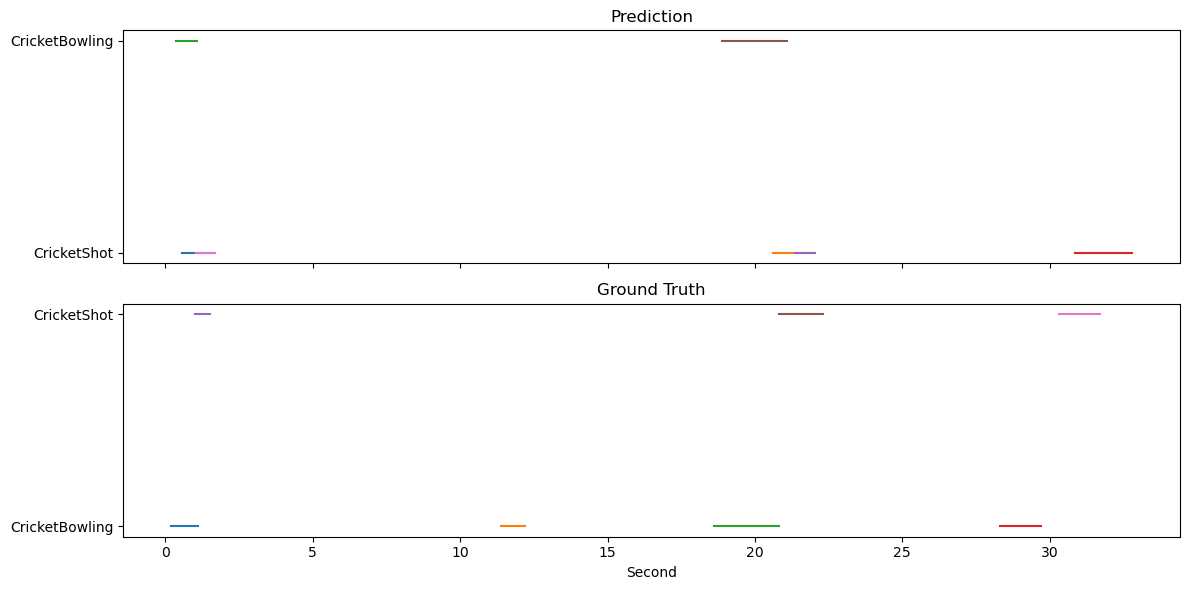

In [8]:
plot_predictions_vs_gt(predictions_df, gt_df, "video_test_0000004", confidence_threshold=0.2)